# Kamera autoencoder - harom architektura osszehasonlitasa

Mindharom modell ugyanazt csinalja: egy 160x80-as CARLA kamerakepet tomorit
**128 dimenzios latens vektorra**, majd visszaepiti. A latens megy majd az RL
agent observationjebe.

| modell | felepites | parameter |
|---|---|---|
| `camera_ae` | sima Conv2d stack | 4.7M |
| `resnet_ae` | residual blokkok + multi-res skip | 2.4M |
| `vgg_ae` | VGG-19 elso negy blokkja (ImageNet elotanitott) | 8.7M |

**A notebook felepitese**

1. Modulok betoltese
2. Adatok betoltese
3. Kozos tanito fuggvenyek
4. `camera_ae` tanitasa + gorbek
5. `resnet_ae` tanitasa + gorbek
6. `vgg_ae` tanitasa + gorbek
7. **Osszehasonlitas** azonos kepeken

Minden modell a sajat `camera/<nev>.ckpt` fajljaba mentodik, es minden
tanitas utan felszabadul a VRAM.

## 1. Modulok betoltese

In [12]:
import gc
import glob
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

from camera.camera_ae import CameraAutoEncoder
from camera.resnet_ae import ResNetAE
from camera.vgg_ae import VGGAE

DATA_DIR = "dataset/camera"
LATENT_DIM = 128          # mindharom modellnek ugyanaz

# MIERT 64 ES NEM TOBB: egy ures 8 GB-os kartyan merve a legnagyobb befero
# batch modellenkent camera_ae=512, resnet_ae=192, vgg_ae=64. A kozos ertek
# tehat 64 - es ez igy is van jol, ket okbol:
#
#   1. Ha mindharom mas batch-et kapna, mar nem a HALOKAT hasonlitanank
#      ossze, hanem a beallitasokat.
#   2. A nagyobb batch nem automatikusan jobb: ugyanannyi epoch alatt
#      kevesebb sulyfrissites tortenik (512-nel nyolcadannyi, mint 64-nel),
#      ami jellemzoen ROSSZABB vegeredmenyt ad, hacsak az lr-t is nem emeled.
BATCH = 64

# MIERT 50 ES NEM 30: az elso futasban a camera_ae a 30. epochban erte el a
# legjobb val loss-t (0.00087) - vagyis NEM allt le magatol, egyszeruen
# elfogyott a keret. Az early stopping (patience=5) leallitja azt a modellt,
# amelyik kitanult, tehat a felso hatar emelese nem pazarlas: csak teret ad
# annak, amelyik meg javul.
EPOCHS = 50

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# A keveres seedje. Kulon tartjuk a globalis seedtol, hogy a batch-ek
# sorrendje reprodukalhato legyen (lasd a 2. szekciot).
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

print(DEVICE, torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

cuda NVIDIA GeForce RTX 4070 Laptop GPU


In [13]:
def free_vram(*objects):
    """Modellek/tenzorok eldobasa es a GPU cache uritese.

    MIERT KELL: harom modellt tanitunk egymas utan. A PyTorch nem adja
    vissza magatol a memoriat az operacios rendszernek - a cache-ben tartja
    ujrahasznositasra. Ha nem uritjuk, a masodik/harmadik tanitas
    'CUDA out of memory'-val elszall egy 8 GB-os kartyan.
    """
    for o in objects:
        if hasattr(o, "cpu"):
            o.cpu()
        del o
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def vram():
    """Aktualis GPU memoriahasznalat GB-ban."""
    if not torch.cuda.is_available():
        return "n/a"
    return (f"{torch.cuda.memory_allocated() / 1e9:.2f} GB foglalt / "
            f"{torch.cuda.memory_reserved() / 1e9:.2f} GB fenntartva")


print("indulaskor:", vram())

indulaskor: 0.17 GB foglalt / 2.80 GB fenntartva


## 2. Adatok betoltese

A `dataset/camera/` mappa PNG-i. A kepek 20 Hz-cel, idorendben keszultek -
ezert **keverni kell** oket, kulonben egy batch ugyanannak a par masodpercnek
a majdnem azonos kepeibol allna, es a gradiens torzitana.

**Harom halmazra vagunk, nem kettore.** Ez fontos, mert a validacios
halmazt KETSZER hasznaljuk: egyreszt az early stopping azon dont (mikor
alljunk le), masreszt a legjobb epoch sulyait is az alapjan valasztjuk ki.
Vagyis a modell - kozvetve - igazodik a val halmazhoz, igy a val loss mar
nem fuggetlen meres, hanem egy szam, amire optimalizaltunk.

| halmaz | arany | mire valo | ki latja |
|---|---|---|---|
| train | 70% | sulyfrissites | a modell tanul belole |
| val | 15% | early stopping, legjobb epoch | a modell kozvetve igazodik hozza |
| test | 15% | a vegso, becsuletes szam | **senki, egyetlen egyszer a vegen** |

A `torch` nem csinalja magatol ezt a vagast - van `random_split`, de az is
csak annyit tesz, amit megadsz neki. Itt kezzel vagunk, hogy lassd, mi
tortenik.

> **Egy figyelmeztetes a veletlen vagasrol.** A kepek 20 Hz-cel keszultek,
> tehat ket szomszedos frame majdnem azonos. Veletlen vagasnal elofordul,
> hogy az egyik a trainbe, a masik a testbe kerul - ilyenkor a teszt olyasmit
> mer, amit a modell gyakorlatilag mar latott, es a szam kicsit optimista
> lesz. Egy szigorubb valtozat idoblokkokat vagna szet (pl. az utolso 15%
> frame legyen a teszt), de az mas palyareszt/fenyviszonyt merne, ami
> nehezebb feladat. Itt a veletlen vagast hasznaljuk.

**Ket helyen kell keverni, ket kulonbozo okbol:**

1. **A train/val vagas elott, egyszer.** Ha idorendben vagnank, a validacios
   halmaz a felvetel egyik vegebol jonne - mas utszakasz, mas fenyviszonyok,
   mint a tanito reszben. Akkor nem azt mernenk, hogy a modell altalanosit,
   hanem azt, hogy atvisz-e egyik palyareszrol a masikra.

2. **Minden epochban ujra, a batch-eken belul.** Ha minden epochban ugyanaz a
   batch-osszeallitas ismetlodne, az optimizer ugyanazt a gradiens-sorozatot
   latna korbe-korbe, es beleragadhatna egy mintazatba. Ezt a
   `DataLoader(shuffle=True)` intezi.

> **Amit a keveres NEM old meg.** Az elso futasban a `resnet_ae` val loss-a a
> 20. epochban megugrott (0.00098 -> 0.00434), majd negy epoch alatt
> visszamaszott. Ez NEM a keveres hianya volt: a keveres mar akkor is ment,
> es ha az lenne a baj, az elso epochban jelentkezne, nem a huszadikban -
> raadasul a `camera_ae`-t is erintene, ugyanazon az adaton.
>
> A valoszinu ok a gradiens: a `resnet_ae` multi-res skipjein tobb uton
> adodik ossze a gradiens, es az `lr=1e-3` fix marad akkor is, amikor a
> veszteseg mar lelaposodott - ilyenkor egy nagy lepes at tud lonni a
> volgyon. A checkpointot ez nem rontotta el (a legjobb sulyokat mentjuk,
> azok a spike elottrol valok), de a modell elvesztett par epochot a
> visszamaszasra.

In [14]:
def load_images(data_dir=DATA_DIR):
    """PNG-k -> (N, 3, 80, 160) float32 [0,1]."""
    paths = sorted(glob.glob(os.path.join(data_dir, "*.png")))
    out = np.empty((len(paths), 80, 160, 3), dtype=np.uint8)
    for i, p in enumerate(tqdm(paths, desc="betoltes", unit="kep")):
        out[i] = np.asarray(Image.open(p).convert("RGB"))
    return torch.from_numpy(out).permute(0, 3, 1, 2).float().div_(255.0)


t0 = time.time()
images = load_images()
print(f"{tuple(images.shape)}  {images.numel() * 4 / 1e9:.1f} GB  "
      f"({time.time() - t0:.0f} s)")
print(f"ertekek [{images.min():.2f}, {images.max():.2f}]  atlag {images.mean():.3f}")

betoltes:   0%|          | 0/54326 [00:00<?, ?kep/s]

(54326, 3, 80, 160)  8.3 GB  (16 s)
ertekek [0.00, 1.00]  atlag 0.541


In [15]:
# --- 1. Keveres a vagas elott ---
# Sajat generator, hogy a permutacio fuggetlen legyen attol, hany veletlen
# szamot hasznalt el addig barmi mas a notebookban - igy ujrafuttatasnal
# ugyanaz a vagas jon ki.
g_split = torch.Generator().manual_seed(SEED)
images = images[torch.randperm(len(images), generator=g_split)]

# --- 2. Harmas vagas: 70% train / 15% val / 15% test ---
n_total = len(images)
n_val = int(n_total * 0.15)
n_test = int(n_total * 0.15)

x_val = images[:n_val]
x_test = images[n_val:n_val + n_test]
x_train = images[n_val + n_test:]

# A teljes tombre mar nincs szukseg, es ez a legnagyobb memoriafogyaszto.
del images
gc.collect()

# --- 3. Keveres minden epochban, a batch-eken belul ---
# A DataLoader a sajat generatoraval kever ujra minden epoch elejen.
# Explicit generatorral adjuk at, hogy a batch-sorrend is reprodukalhato
# legyen - kulonben a globalis RNG allapotatol fugg, amit a modell
# inicializalasa is elhasznal, igy a harom modell MAS sorrendet kapna.
def make_train_loader(batch_size=BATCH, seed=SEED):
    """Tanito loader ujrakevert batch-ekkel, reprodukalhato sorrendben."""
    g = torch.Generator().manual_seed(seed)
    return DataLoader(TensorDataset(x_train), batch_size=batch_size,
                      shuffle=True, generator=g, drop_last=True)


# drop_last=True: az utolso, csonka batch-et eldobjuk. Egy 64-es batch utan
# egy 7 elemu batch zajosabb gradienst ad (kevesebb mintan atlagol), es a
# BatchNorm statisztikai is megbizhatatlanabbak rajta.
train_loader = make_train_loader()
val_loader = DataLoader(TensorDataset(x_val), batch_size=BATCH)
test_loader = DataLoader(TensorDataset(x_test), batch_size=BATCH)

print(f"train {len(x_train):6d}  ({100 * len(x_train) / n_total:.0f}%)")
print(f"val   {len(x_val):6d}  ({100 * len(x_val) / n_total:.0f}%)")
print(f"test  {len(x_test):6d}  ({100 * len(x_test) / n_total:.0f}%)  <- csak a vegen")
print(f"\nbatch {BATCH}, train batch-ek {len(train_loader)}, "
      f"eldobott csonka batch: {len(x_train) % BATCH} kep")

train  38030  (70%)
val     8148  (15%)
test    8148  (15%)  <- csak a vegen

batch 64, train batch-ek 594, eldobott csonka batch: 14 kep


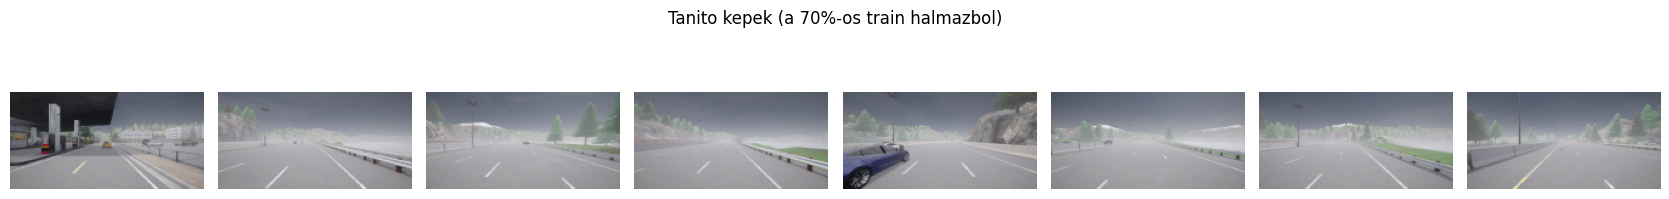

In [16]:
def show(x, n=8, title=""):
    """Nehany kep megjelenitese."""
    idx = np.random.choice(len(x), n, replace=False)
    fig, axes = plt.subplots(1, n, figsize=(2.1 * n, 2.4))
    for ax, i in zip(axes, idx):
        ax.imshow(x[i].permute(1, 2, 0).numpy())
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show(x_train, title="Tanito kepek (a 70%-os train halmazbol)")

## 3. Kozos tanito fuggvenyek

Mindharom modell UGYANAZZAL a fuggvennyel tanul, ugyanazon az adaton es
ugyanazzal a loss-szal (MSE) - kulonben nem a halokat hasonlitanank ossze,
hanem a tanitasi beallitasokat.

In [17]:
def evaluate(model, loader):
    """Atlagos MSE a teljes loaderen."""
    model.eval()
    total = 0.0
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            total += F.mse_loss(model(xb), xb).item() * len(xb)
    return total / len(loader.dataset)


def train_model(model, label, epochs=EPOCHS, lr=1e-3, patience=8,
                batch=None, clip=1.0, lr_min=1e-5):
    """Tanitas MSE-vel. A vegen a LEGJOBB val loss-hoz tartozo sulyok maradnak.

    A visszaadott dict tartalmazza a gorbeket es a ckpt utvonalat, de a
    MODELLT NEM - az a tanitas vegen lekerul a GPU-rol es felszabadul.
    Az osszehasonlitashoz a checkpointbol toltjuk vissza.

    HAROM DOLOG A PONTOSABB EREDMENYERT (az elso futas tanulsagai alapjan):

    clip=1.0 - gradient clipping. Az elso futasban a resnet_ae val loss-a a
        20. epochban megugrott (0.00098 -> 0.00434), es negy epoch kellett a
        visszamaszasra. Egy kiugro gradiens kilokte a sulyokat. A clipping
        levagja a tul nagy gradienseket (a norma 1.0-ra), a normal lepeseket
        nem erinti. Kulonosen a resnet_ae-nek szamit, ahol a multi-res
        skipeken TOBB uton adodik ossze a gradiens.

    lr_min=1e-5 - koszinusz utemezes (CosineAnnealingLR). A tanulasi rata
        SIMAN csokken lr-rol lr_min-re a futas alatt, fuggetlenul attol,
        javul-e eppen a val loss.

        MIERT EZ, ES NEM ReduceLROnPlateau: eloszor azt hasznaltuk, de a
        merés szerint SOSEM lepett. A resnet_ae 50 epochjan at vegig
        1e-3 maradt az lr, mert a plateau-scheduler csak akkor felez, ha 3
        egymast koveto epochon at nincs uj rekord - a resnetnel viszont
        majdnem minden 2-3. epochban szuletett uj legjobb ertek (a javulas
        lassu volt, de letezett), igy a szamlalo folyton nullazodott.

        Az OSZCILLACIO valodi oka: a kesoi fazisban az lr=1e-3 mar tul nagy.
        A modell a volgy aljan at-meg-at ugrik, nem tud beleulni - a val
        loss ezert pattog +-2%-ot (a train loss is, csak kisebb
        amplitudoval, tehat nem a val halmaz zaja a hibas). A koszinusz
        utemezes ezt kezeli: a vegere a lepeskoz a szazada lesz a
        kezdetinek, es a gorbe lesimul.

    patience=8 - early stopping (korabban 5). Egy zajos val loss mellett az
        5 tul szoros: egy szerencses epoch utan indul a szamlalo, es a modell
        leallhat, mikozben meg tanulna. A resnet_ae igy allt le 24-nel.
    """
    # Sajat batch meret, ha a modell nem fer be az alapertelmezettel.
    # Ugyanazt a fuggvenyt hasznaljuk, mint fent, hogy a keveres es a
    # drop_last viselkedes azonos legyen minden modellnel - kulonben nem a
    # halokat hasonlitanank ossze, hanem a betoltesi beallitasokat.
    loader = train_loader
    if batch is not None and batch != BATCH:
        loader = make_train_loader(batch_size=batch)

    model = model.to(DEVICE)
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.Adam(params, lr=lr)

    # Koszinusz utemezes: az lr simán megy le lr-rol lr_min-re `epochs`
    # lepes alatt. Nem figyel semmilyen metrikat - ez szandekos, lasd a
    # docstringet.
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=epochs, eta_min=lr_min)

    hist = {"label": label, "arch": type(model).__name__,
            "train": [], "val": [], "lr": [], "best": float("inf"),
            "params": sum(p.numel() for p in model.parameters()),
            "ckpt": f"camera/{label}.ckpt"}
    best_state, bad = None, 0

    print(f"{label}  ({hist['params'] / 1e6:.1f}M parameter, lr={lr}, "
          f"batch={batch or BATCH}, clip={clip})")
    t0 = time.time()

    for ep in range(1, epochs + 1):
        model.train()
        run = 0.0
        bar = tqdm(loader, desc=f"epoch {ep}/{epochs}", leave=False)
        for (xb,) in bar:
            xb = xb.to(DEVICE)
            loss = F.mse_loss(model(xb), xb)
            opt.zero_grad()
            loss.backward()
            # A clipping a backward UTAN es a step ELOTT all: ekkor mar
            # kesz a gradiens, de meg nem frissultek a sulyok.
            if clip is not None:
                torch.nn.utils.clip_grad_norm_(params, clip)
            opt.step()
            run += loss.item() * len(xb)
            bar.set_postfix(loss=f"{loss.item():.5f}")

        # drop_last=True miatt nem a teljes datasetet latjuk vegig egy
        # epochban, ezert a TENYLEGESEN feldolgozott mintakkal osztunk.
        tr = run / (len(loader) * loader.batch_size)
        va = evaluate(model, val_loader)
        hist["train"].append(tr)
        hist["val"].append(va)

        # Az aktualis lr-t elmentjuk, hogy a gorben lassuk, hogyan csokkent.
        # A CosineAnnealingLR-t argumentum nelkul leptetjuk (a plateau-val
        # ellentetben nem nez metrikat).
        hist["lr"].append(opt.param_groups[0]["lr"])
        sched.step()

        # Early stopping: ha `patience` epochon at nem javul a val loss,
        # megallunk. A tullanulas ellen ved es idot sporol.
        if va < hist["best"]:
            hist["best"], bad = va, 0
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                print(f"  early stop ({patience} epoch javulas nelkul)")
                break

        print(f"  epoch {ep:2d}  train {tr:.5f}  val {va:.5f}"
              f"  lr {hist['lr'][-1]:.2e}{'  *' if bad == 0 else ''}")

    model.load_state_dict(best_state)
    hist["epochs_run"] = len(hist["train"])
    hist["time"] = time.time() - t0

    # MENTES sajat nevvel. Az arch is bekerul, hogy visszatoltesnel tudd,
    # melyik architekturarol van szo.
    torch.save({"state_dict": best_state,
                "hparams": dict(model.hparams),
                "arch": hist["arch"],
                "best_val": hist["best"],
                "train": hist["train"], "val": hist["val"],
                "lr": hist["lr"]}, hist["ckpt"])

    print(f"  mentve: {hist['ckpt']}  (best val {hist['best']:.5f}, "
          f"{hist['time'] / 60:.1f} perc)")
    return hist, model


def plot_history(hist):
    """Egy modell tanulasi gorbeje, a tanulasi rata lefutasaval egyutt.

    A masodik (jobb oldali) tengely az lr - igy latszik, hogy a gorbe
    lesimulasa egybeesik-e az lr csokkenesevel.
    """
    ep = list(range(1, len(hist["train"]) + 1))
    fig, ax = plt.subplots(figsize=(7.5, 4))

    ax.plot(ep, hist["train"], "-o", ms=3, label="train")
    ax.plot(ep, hist["val"], "-s", ms=3, label="val")
    ax.axhline(hist["best"], ls=":", c="gray",
               label=f"best val {hist['best']:.5f}")
    ax.set_xlabel("epoch")
    ax.set_ylabel("MSE")
    ax.set_yscale("log")
    ax.grid(alpha=0.3)

    lrs = hist.get("lr", [])
    if lrs:
        ax2 = ax.twinx()
        ax2.plot(ep[:len(lrs)], lrs, color="tab:orange", alpha=0.6, lw=1.2)
        ax2.set_ylabel("tanulasi rata", color="tab:orange")
        ax2.tick_params(axis="y", labelcolor="tab:orange")
        ax2.set_yscale("log")
        ax.plot([], [], color="tab:orange", alpha=0.6, lw=1.2, label="lr")

    ax.legend(loc="upper right")
    ax.set_title(f"{hist['label']}  ({hist['params'] / 1e6:.1f}M parameter)")
    plt.tight_layout()
    plt.show()

## 4. `camera_ae`

### Felepites

Negy `Conv2d(kernel=4, stride=2)` blokk, mindegyik felezi a meretet:

```
(3, 80, 160) -> (32, 40, 80) -> (64, 20, 40) -> (128, 10, 20) -> (256, 5, 10)
```

Utana `flatten` (12800) es egyetlen `Linear(12800 -> 128)`.
A dekoder ennek pontos tukorkepe `ConvTranspose2d` retegekkel.

camera_ae  (4.7M parameter, lr=0.001, batch=64, clip=1.0)


epoch 1/50:   0%|          | 0/594 [00:00<?, ?it/s]

  epoch  1  train 0.00426  val 0.00302  lr 1.00e-03  *


epoch 2/50:   0%|          | 0/594 [00:00<?, ?it/s]

  epoch  2  train 0.00276  val 0.00249  lr 9.99e-04  *


...

  epoch 48  train 0.00070  val 0.00084  lr 1.88e-05  *


epoch 49/50:   0%|          | 0/594 [00:00<?, ?it/s]

  epoch 49  train 0.00070  val 0.00084  lr 1.39e-05


epoch 50/50:   0%|          | 0/594 [00:00<?, ?it/s]

  epoch 50  train 0.00070  val 0.00084  lr 1.10e-05
  mentve: camera/camera_ae.ckpt  (best val 0.00084, 9.8 perc)


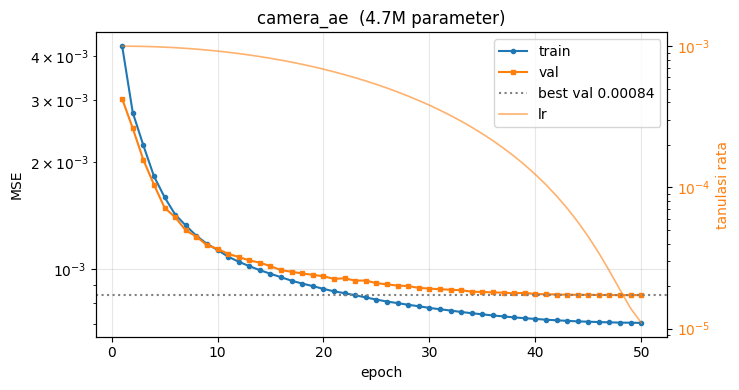

In [18]:
model = CameraAutoEncoder(latent_dim=LATENT_DIM)
hist_camera_ae, model = train_model(model, label="camera_ae", lr=1e-3)

plot_history(hist_camera_ae)

In [19]:
# VRAM felszabaditasa a kovetkezo modell elott.
# A sulyok mar a camera/camera_ae.ckpt fajlban vannak, a modell elengedheto.
free_vram(model)
print("camera_ae utan:", vram())

camera_ae utan: 0.17 GB foglalt / 0.40 GB fenntartva


## 5. `resnet_ae`

### Felepites

Residual blokkok (`x + F(x)`) negy szinten, **multi-resolution skip**
kapcsolatokkal: minden szint kimenete kap egy rovidzarat egyenesen a
bottleneck ele, igy a finom reszletek is eljutnak a latensig.

> A `n_ResidualBlock` alapertelmezese **2** (nem az eredeti 8).
> Merve azonos idokeretben a 2 adja a legjobb eredmenyt: kevesebb reteg
> -> gyorsabb lepes -> tobb lepes ugyanannyi ido alatt.

resnet_ae  (2.4M parameter, lr=0.001, batch=64, clip=1.0)


epoch 1/50:   0%|          | 0/594 [00:00<?, ?it/s]

  epoch  1  train 0.00545  val 0.00404  lr 1.00e-03  *


epoch 2/50:   0%|          | 0/594 [00:00<?, ?it/s]

  epoch  2  train 0.00344  val 0.00319  lr 9.99e-04  *


...

  epoch 48  train 0.00153  val 0.00163  lr 1.88e-05


epoch 49/50:   0%|          | 0/594 [00:00<?, ?it/s]

  epoch 49  train 0.00153  val 0.00163  lr 1.39e-05  *


epoch 50/50:   0%|          | 0/594 [00:00<?, ?it/s]

  epoch 50  train 0.00153  val 0.00163  lr 1.10e-05  *
  mentve: camera/resnet_ae.ckpt  (best val 0.00163, 51.2 perc)


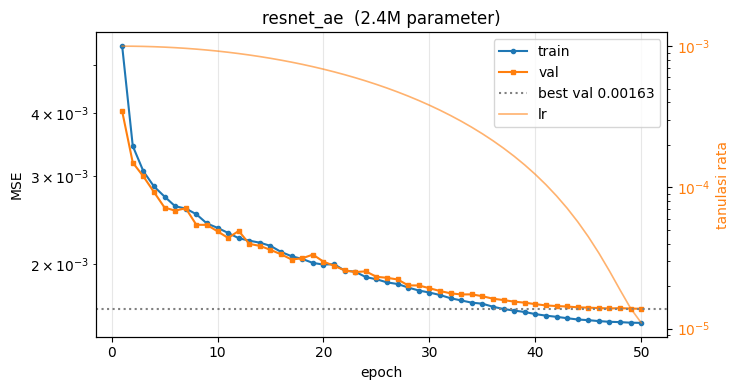

In [20]:
model = ResNetAE(latent_dim=LATENT_DIM)
hist_resnet_ae, model = train_model(model, label="resnet_ae", lr=1e-3)

plot_history(hist_resnet_ae)

In [21]:
# VRAM felszabaditasa a kovetkezo modell elott.
# A sulyok mar a camera/resnet_ae.ckpt fajlban vannak, a modell elengedheto.
free_vram(model)
print("resnet_ae utan:", vram())

resnet_ae utan: 0.17 GB foglalt / 0.40 GB fenntartva


## 6. `vgg_ae`

### Felepites

A VGG-19 elso negy blokkja (a `relu4_1` retegig) encoderkent,
**ImageNet-en elotanitott sulyokkal**. A dekoder ennek tukorkepe.

> **Ket kulonbseg a masik kettohoz kepest:**
> - `lr=1e-4`, nem `1e-3`. Ez a halo 22 konvolucios reteg normalizalas
>   nelkul; 1e-3 mellett merve elszall (a loss 0.09-rol 0.33-ra ugrik).
> - Az elotanitott sulyok **kotelezoek**: veletlen indulasbol a jel elhal
>   a melyeben, es a halo egyaltalan nem tanul.

vgg_ae  (8.7M parameter, lr=0.0001, batch=64, clip=1.0)


epoch 1/50:   0%|          | 0/594 [00:00<?, ?it/s]

  epoch  1  train 0.00381  val 0.00252  lr 1.00e-04  *


epoch 2/50:   0%|          | 0/594 [00:00<?, ?it/s]

  epoch  2  train 0.00211  val 0.00191  lr 9.99e-05  *


...

  epoch 48  train 0.00067  val 0.00080  lr 1.08e-05  *


epoch 49/50:   0%|          | 0/594 [00:00<?, ?it/s]

  epoch 49  train 0.00066  val 0.00080  lr 1.04e-05  *


epoch 50/50:   0%|          | 0/594 [00:00<?, ?it/s]

  epoch 50  train 0.00066  val 0.00080  lr 1.01e-05  *
  mentve: camera/vgg_ae.ckpt  (best val 0.00080, 192.8 perc)


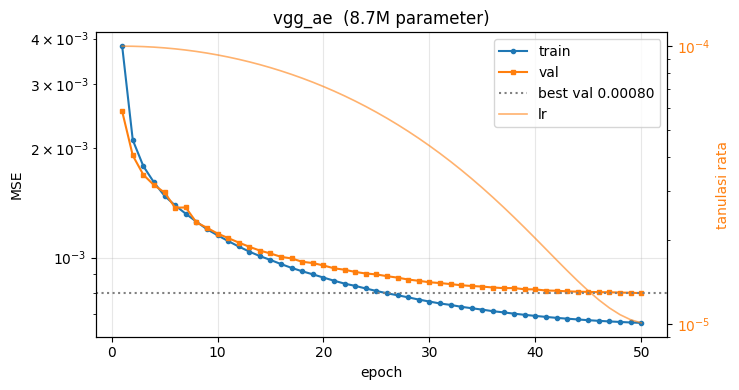

In [22]:
# A VGG a legnagyobb halo (8.7M parameter, 22 konvolucios reteg), ezert
# tobb aktivaciot tarol a backwardhoz. Ujramerve egy URES 8 GB-os kartyan:
# batch=64 eseten a csucs 4.26 GB - befer, tehat ugyanazt a batch meretet
# kapja, mint a masik ketto. (batch=96 mar OOM.)
#
# FIGYELEM: ha kozben mas is hasznalja a GPU-t (pl. egy masik notebook
# kernel), a 4.26 GB mar nem fer be. Olyankor allitsd vissza batch=32-re.
model = VGGAE(latent_dim=LATENT_DIM)
hist_vgg_ae, model = train_model(model, label="vgg_ae", lr=1e-4)

plot_history(hist_vgg_ae)

In [23]:
# VRAM felszabaditasa a kovetkezo modell elott.
# A sulyok mar a camera/vgg_ae.ckpt fajlban vannak, a modell elengedheto.
free_vram(model)
print("vgg_ae utan:", vram())

vgg_ae utan: 0.17 GB foglalt / 0.40 GB fenntartva


## 7. Osszehasonlitas

A modelleket a mentett checkpointokbol toltjuk vissza, es a **test halmazon**
mertunk - azon a 15%-on, amit egyik modell sem latott, es ami az early
stopping dontesebe sem szolt bele.

Ezert a test szam a becsuletes ertek: ezt varhatod a gyakorlatban is. A val
loss ennel jellemzoen optimistabb, mert arra kozvetve optimalizaltunk.

In [24]:
HISTORIES = [hist_camera_ae, hist_resnet_ae, hist_vgg_ae]
ARCHS = {"CameraAutoEncoder": CameraAutoEncoder,
         "ResNetAE": ResNetAE,
         "VGGAE": VGGAE}


def load_model(hist):
    """Modell visszatoltese a checkpointbol."""
    ck = torch.load(hist["ckpt"], map_location="cpu", weights_only=False)
    hp = dict(ck["hparams"])
    # A VGG-nel az elotanitott sulyok letoltese felesleges: a ckpt-bol
    # ugyis felulirjuk oket.
    if ck["arch"] == "VGGAE":
        hp["pretrained"] = False
    m = ARCHS[ck["arch"]](**hp)
    m.load_state_dict(ck["state_dict"])
    return m.eval()


print("Mentett checkpointok:")
for h in HISTORIES:
    size = os.path.getsize(h["ckpt"]) / 1e6
    print(f"  {h['ckpt']:28s} {size:6.1f} MB   best val {h['best']:.5f}")

Mentett checkpointok:
  camera/camera_ae.ckpt          18.7 MB   best val 0.00084
  camera/resnet_ae.ckpt           9.9 MB   best val 0.00163
  camera/vgg_ae.ckpt             34.8 MB   best val 0.00080


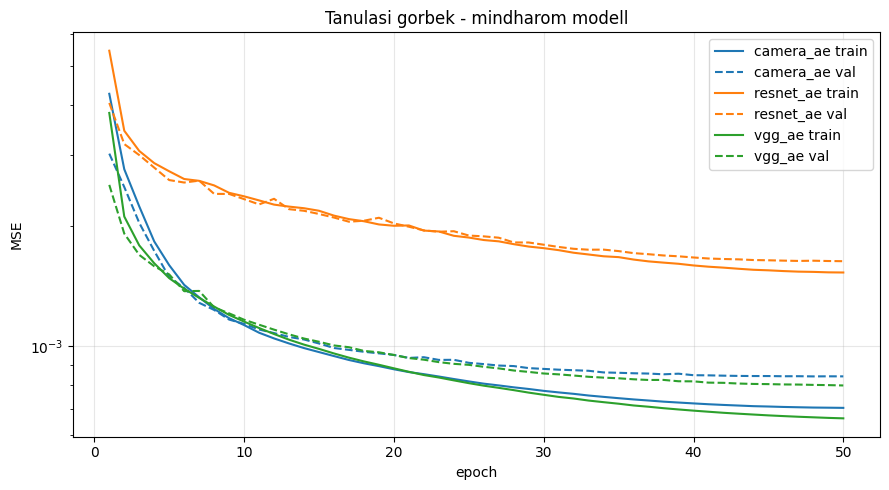

In [25]:
# --- Tanulasi gorbek egyutt ---
plt.figure(figsize=(9, 5))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for k, h in enumerate(HISTORIES):
    ep = range(1, len(h["train"]) + 1)
    plt.plot(ep, h["train"], "-", color=colors[k], label=f"{h['label']} train")
    plt.plot(ep, h["val"], "--", color=colors[k], label=f"{h['label']} val")

plt.xlabel("epoch")
plt.ylabel("MSE")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.legend()
plt.title("Tanulasi gorbek - mindharom modell")
plt.tight_layout()
plt.show()

In [26]:
# --- Szamszeru osszehasonlitas a TEST halmazon ---
# A PSNR beszedesebb, mint a nyers MSE: dB-ben meri a jel/zaj aranyt.
# Referencia: 30 dB folott a kulonbseg szabad szemmel alig lathato.
#
# A 'val' oszlop az, ami alapjan a legjobb epochot valasztottuk; a 'test'
# oszlop a fuggetlen meres. Ha a ketto kozott nagy a kulonbseg, az azt
# jelenti, hogy a modell ratanult a validacios halmazra.

rows = []
for h in HISTORIES:
    m = load_model(h).to(DEVICE)
    test_mse = evaluate(m, test_loader)
    free_vram(m)

    h["test"] = test_mse            # eltesszuk a kesobbi cellaknak
    psnr = 10 * np.log10(1.0 / test_mse)
    px = np.sqrt(test_mse) * 255    # tipikus pixelhiba 0-255 skalan
    rows.append((h["label"], h["best"], test_mse, psnr, px,
                 h["params"] / 1e6, h["epochs_run"], h["time"] / 60))

rows.sort(key=lambda r: r[2])       # test MSE szerint rendezve

print(f"{'modell':14s} {'val MSE':>9s} {'test MSE':>9s} {'PSNR':>8s} "
      f"{'pixelhiba':>10s} {'param':>8s} {'epoch':>6s} {'perc':>6s}")
print("-" * 82)
for r in rows:
    print(f"{r[0]:14s} {r[1]:9.5f} {r[2]:9.5f} {r[3]:7.2f}dB {r[4]:9.1f} "
          f"{r[5]:7.1f}M {r[6]:6d} {r[7]:6.1f}")

print(f"\nLEGJOBB: {rows[0][0]}  (test MSE {rows[0][2]:.5f}, "
      f"PSNR {rows[0][3]:.2f} dB)")

# Mennyivel optimistabb a val, mint a test? Nagy elteres = ratanulas.
gap = 100 * (rows[0][2] - rows[0][1]) / rows[0][1]
print(f"A gyoztesnel a test {gap:+.1f}%-kal ter el a val loss-tol.")

modell           val MSE  test MSE     PSNR  pixelhiba    param  epoch   perc
----------------------------------------------------------------------------------
vgg_ae           0.00080   0.00079   31.01dB       7.2     8.7M     50  192.8
camera_ae        0.00084   0.00083   30.79dB       7.4     4.7M     50    9.8
resnet_ae        0.00163   0.00162   27.90dB      10.3     2.4M     50   51.2

LEGJOBB: vgg_ae  (test MSE 0.00079, PSNR 31.01 dB)
A gyoztesnel a test -0.9%-kal ter el a val loss-tol.


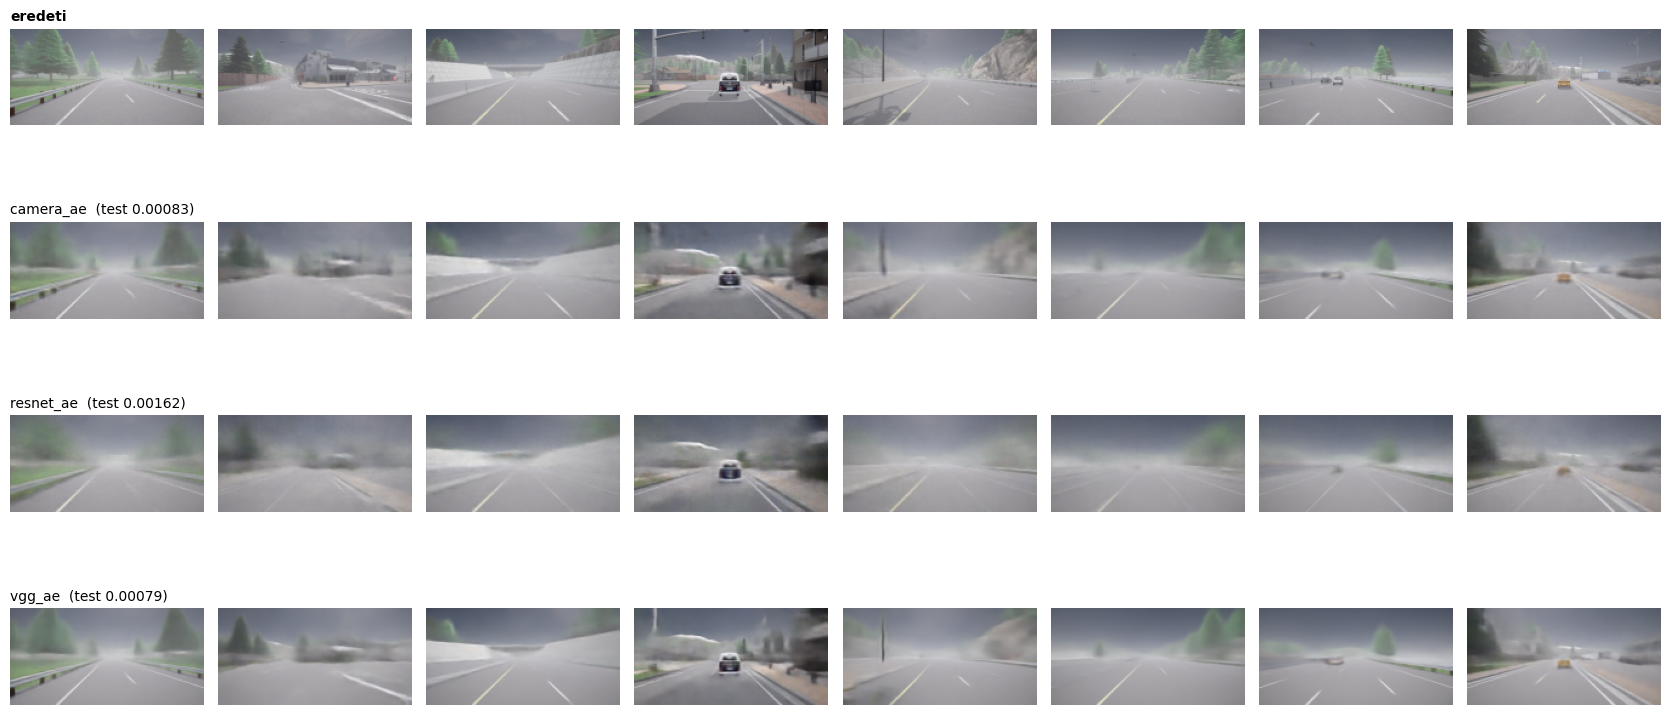

VRAM: 0.17 GB foglalt / 0.40 GB fenntartva


In [ ]:

# --- Rekonstrukciok egymas alatt, UGYANAZOKON a kepeken ---
# A TEST halmazbol valasztunk, hogy tenyleg nem latott kepeket lassunk.
n = 8
idx = np.random.choice(len(x_test), n, replace=False)
orig = x_test[idx]

fig, axes = plt.subplots(len(HISTORIES) + 1, n,
                         figsize=(2.1 * n, 2.1 * (len(HISTORIES) + 1)))

for j in range(n):
    axes[0, j].imshow(orig[j].permute(1, 2, 0).numpy())
    axes[0, j].axis("off")
axes[0, 0].set_title("eredeti", loc="left", fontsize=10, weight="bold")

for i, h in enumerate(HISTORIES, start=1):
    m = load_model(h).to(DEVICE)
    with torch.no_grad():
        rec = m(orig.to(DEVICE)).cpu().clamp(0, 1)
    free_vram(m)                      # minden modell utan takaritunk

    for j in range(n):
        axes[i, j].imshow(rec[j].permute(1, 2, 0).numpy())
        axes[i, j].axis("off")
    axes[i, 0].set_title(f"{h['label']}  (test {h['test']:.5f})",
                         loc="left", fontsize=10)

plt.tight_layout()
plt.show()
print("VRAM:", vram())

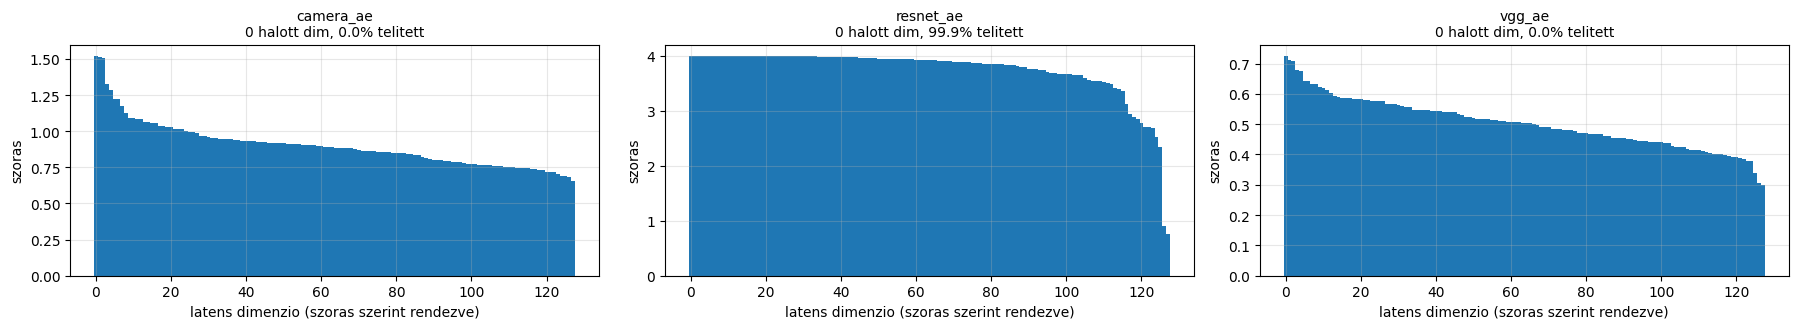

VRAM: 0.17 GB foglalt / 0.40 GB fenntartva


In [28]:
# --- Kihasznaljak-e a modellek a latens teret? ---
#
# halott dimenzio : akinek a szorasa ~0, az nem hordoz informaciot
# telitett        : a tanh hataran (+-latent_scale) ulo ertekek - ezek
#                   gradiense majdnem nulla, tehat mar nem tanulnak

n_sample = min(1000, len(x_test))
sidx = np.random.choice(len(x_test), n_sample, replace=False)
sample = x_test[sidx]

fig, axes = plt.subplots(1, len(HISTORIES), figsize=(6 * len(HISTORIES), 3.4),
                         squeeze=False)

for k, h in enumerate(HISTORIES):
    m = load_model(h).to(DEVICE)
    scale = m.hparams.latent_scale
    with torch.no_grad():
        z = m.encode(sample.to(DEVICE)).cpu().numpy()
    free_vram(m)

    std = z.std(axis=0)
    dead = int((std < 0.01 * scale).sum())
    sat = 100 * (np.abs(z) > 0.97 * scale).mean()

    ax = axes[0, k]
    ax.bar(range(len(std)), np.sort(std)[::-1], width=1.0)
    ax.set_title(f"{h['label']}\n{dead} halott dim, {sat:.1f}% telitett",
                 fontsize=10)
    ax.set_xlabel("latens dimenzio (szoras szerint rendezve)")
    ax.set_ylabel("szoras")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("VRAM:", vram())